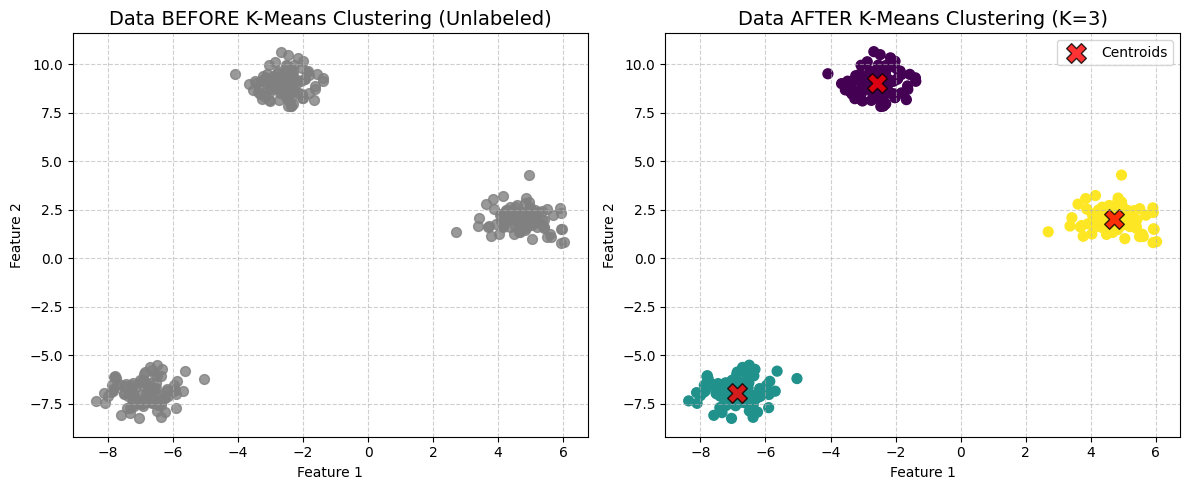


--- K-Means Results ---
The final coordinates of the 3 centroids are:
Cluster 0 Centroid: (-2.58, 9.03)
Cluster 1 Centroid: (-6.88, -6.94)
Cluster 2 Centroid: (4.70, 2.00)

Inertia (WCSS): 204.07


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# --- 1. Data Generation ---
# Generate a synthetic dataset with 3 clear 'blobs' (clusters)
# n_samples: total number of points
# centers: the number of clusters (K)
# random_state: for reproducibility
n_samples = 300
random_seed = 42
K_clusters = 3

X, y_true = make_blobs(n_samples=n_samples, centers=K_clusters,
                       cluster_std=0.60, random_state=random_seed)

# X contains the (x, y) coordinates of the data points
# y_true contains the true labels (which we ignore in K-Means, as it's unsupervised)

# --- 2. Visualization: Data BEFORE K-Means ---
plt.figure(figsize=(12, 5))

# Subplot 1: Unlabeled Data
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, c='gray', alpha=0.8)
plt.title('Data BEFORE K-Means Clustering (Unlabeled)', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)

# --- 3. K-Means Implementation ---
# 1. Initialize the K-Means model
#    n_clusters=K_clusters: The 'K' value we chose (3)
#    init='k-means++': Smart initialization to speed up convergence
#    n_init='auto': Runs K-Means multiple times and returns the best one
kmeans = KMeans(n_clusters=K_clusters, init='k-means++', n_init='auto', random_state=random_seed)

# 2. Fit the model to the data (this runs the iterative assignment and update steps)
kmeans.fit(X)

# 3. Get the results
y_kmeans = kmeans.predict(X)          # The cluster labels (0, 1, or 2) for each point
centers = kmeans.cluster_centers_     # The final coordinates of the 3 centroids

# --- 4. Visualization: Data AFTER K-Means ---

# Subplot 2: Labeled Data
plt.subplot(1, 2, 2)

# Scatter plot of data points, colored by their assigned cluster
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot the centroids
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X',
            edgecolor='black', label='Centroids')

plt.title(f'Data AFTER K-Means Clustering (K={K_clusters})', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 5. Display Final Centroid Coordinates ---
print("\n--- K-Means Results ---")
print(f"The final coordinates of the {K_clusters} centroids are:")
for i, center in enumerate(centers):
    print(f"Cluster {i} Centroid: ({center[0]:.2f}, {center[1]:.2f})")
print(f"\nInertia (WCSS): {kmeans.inertia_:.2f}")

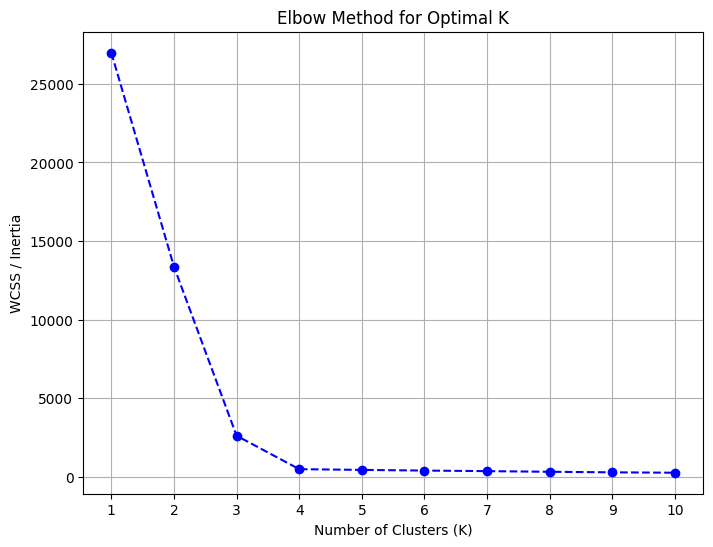

WCSS values for K=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]: [26979.649328312586, 13373.550913836387, 2615.7333416621946, 490.5717148057801, 443.1978120854582, 400.18423908306767, 365.13825159144443, 323.08805323318217, 287.8815818452536, 263.42830447705]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# --- 1. Data Generation (For demonstration) ---
# Generate a dataset with 4 clear clusters
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.8, random_state=42)

# --- 2. Implement the Elbow Method ---
k_range = range(1, 11)
wcss = [] # To store WCSS (Inertia) for each K

for k in k_range:
    # Initialize K-Means with the current K
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto',
                    random_state=42, max_iter=300)
    kmeans.fit(X)

    # Get the WCSS (Inertia) value
    wcss.append(kmeans.inertia_)

# --- 3. Plot the Elbow Curve ---
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Print WCSS values for inspection
print(f"WCSS values for K={list(k_range)}: {wcss}")